In [3]:
import cupy as np
import matplotlib.pyplot as plt
import time

# =============================================================================
# Parameters (MATLAB -> Python)
# =============================================================================
Nx = 10   # number of points in x-direction
Ny = 50   # number of points in y-direction

T = 0.15
beta = 1.0 / T
t = 1.0
V = 1.5
mu = 1.8

# external field
Bx = 0.0  # off-diagonal
Bz = 0.0  # diagonal

# momentum grid (matches MATLAB linspace(pi/Ny, pi, Ny))
ky_list = np.linspace(np.pi / Ny, np.pi, Ny)

AbsTol = 1e-6
RelTol = 1e-4
maxItr = 500

# =============================================================================
# Helpers
# =============================================================================
def g(i_site: int, comp: int) -> int:
    """Global index for site i_site (0..Nx-1) and component comp (0..3)."""
    return 4 * i_site + comp

def fermi_dirac(E, beta):
    """Stable-ish Fermi-Dirac for real E."""
    x = beta * E
    return np.where(x > 50, 0.0, np.where(x < -50, 1.0, 1.0 / (np.exp(x) + 1.0)))

def build_H1(Fx_plus, Fx_min):
    """k-independent Hamiltonian (chemical potential, x-hopping, x-pairing, fields)."""
    dim = 4 * Nx
    H1 = np.zeros((dim, dim), dtype=np.complex128)

    # onsite blocks
    for i in range(Nx):
        # diagonal: chemical potential + Bz
        H1[g(i, 0), g(i, 0)] = -mu + Bz
        H1[g(i, 1), g(i, 1)] = -mu - Bz
        H1[g(i, 2), g(i, 2)] =  mu - Bz
        H1[g(i, 3), g(i, 3)] =  mu + Bz

        # Bx couplings within site block
        H1[g(i, 0), g(i, 1)] = Bx
        H1[g(i, 1), g(i, 0)] = Bx
        H1[g(i, 2), g(i, 3)] = -Bx
        H1[g(i, 3), g(i, 2)] = -Bx

    # x-direction hopping + x-pairing (between i and i+1)
    for i in range(Nx - 1):
        # hopping (same pattern as MATLAB repmat([-t,-t,t,t],..., Nx-1))
        for c, hop in enumerate([-t, -t, t, t]):
            H1[g(i, c),   g(i + 1, c)] = hop
            H1[g(i + 1, c), g(i, c)] = hop

        # superconducting off-diagonal x-terms
        Fx1 = V * Fx_min[i]
        Fx2 = V * Fx_plus[i]

        # Upper (i -> i+1)
        H1[g(i, 0), g(i + 1, 3)] =  Fx2  # (1,4)
        H1[g(i, 1), g(i + 1, 2)] = -Fx1  # (2,3)
        H1[g(i, 2), g(i + 1, 1)] = -Fx2  # (3,2)
        H1[g(i, 3), g(i + 1, 0)] =  Fx1  # (4,1)

        # Lower (i+1 -> i)
        H1[g(i + 1, 0), g(i, 3)] =  Fx1  # (1,4)
        H1[g(i + 1, 1), g(i, 2)] = -Fx2  # (2,3)
        H1[g(i + 1, 2), g(i, 1)] = -Fx1  # (3,2)
        H1[g(i + 1, 3), g(i, 0)] =  Fx2  # (4,1)

    return H1

def build_H0(Fy_plus, Fy_min):
    """k=0 terms (dispersion + onsite y-pairing with no phase)."""
    dim = 4 * Nx
    H0 = np.zeros((dim, dim), dtype=np.complex128)

    # dispersion at ky=0: epsilon = -2t*cos(0) = -2t
    for i in range(Nx):
        H0[g(i, 0), g(i, 0)] = -2 * t
        H0[g(i, 1), g(i, 1)] = -2 * t
        H0[g(i, 2), g(i, 2)] =  2 * t
        H0[g(i, 3), g(i, 3)] =  2 * t

        Fy_14 = V * (Fy_plus[i] + Fy_min[i])
        Fy_23 = -V * (Fy_plus[i] + Fy_min[i])

        H0[g(i, 0), g(i, 3)] = Fy_14
        H0[g(i, 1), g(i, 2)] = Fy_23
        H0[g(i, 2), g(i, 1)] = np.conj(Fy_23)
        H0[g(i, 3), g(i, 0)] = np.conj(Fy_14)

    return H0

def build_H2(Fy_plus, Fy_min, ky):
    """k-dependent terms for a given ky (dispersion + onsite y-pairing with phases)."""
    dim = 4 * Nx
    H2 = np.zeros((dim, dim), dtype=np.complex128)

    epsilon = -2 * t * np.cos(ky)
    e = np.exp(1j * ky)
    em = np.exp(-1j * ky)

    for i in range(Nx):
        # dispersion
        H2[g(i, 0), g(i, 0)] =  epsilon
        H2[g(i, 1), g(i, 1)] =  epsilon
        H2[g(i, 2), g(i, 2)] = -epsilon
        H2[g(i, 3), g(i, 3)] = -epsilon

        # y-pairing with phase
        Fy_14 = V * (Fy_plus[i] * em + Fy_min[i] * e)
        Fy_23 = -V * (Fy_plus[i] * e + Fy_min[i] * em)

        H2[g(i, 0), g(i, 3)] = Fy_14
        H2[g(i, 1), g(i, 2)] = Fy_23
        H2[g(i, 2), g(i, 1)] = np.conj(Fy_23)
        H2[g(i, 3), g(i, 0)] = np.conj(Fy_14)

    return H2

# =============================================================================
# Initial order parameters (MATLAB -> Python)
# =============================================================================
Fx_plus = 0.1 * np.ones(Nx - 1, dtype=np.complex128)
Fx_min  = -0.1 * np.ones(Nx - 1, dtype=np.complex128)
Fy_plus = 0.1j * np.ones(Nx, dtype=np.complex128)
Fy_min  = -0.1j * np.ones(Nx, dtype=np.complex128)

# differences + loop conditions
absdiff1 = absdiff2 = absdiff3 = absdiff4 = 100.0
reldiff1 = reldiff2 = reldiff3 = reldiff4 = 100.0
Itr = 0

c1 = True
c2 = True
c3 = True

# =============================================================================
# Iteration
# =============================================================================
t0 = time.perf_counter()

while c1 and c2 and c3:
    H1 = build_H1(Fx_plus, Fx_min)
    H0 = build_H0(Fy_plus, Fy_min)

    # Diagonalize k=0 block
    Hk0 = H0 + H1
    # (optional) symmetrize to reduce numerical drift
    Hk0 = 0.5 * (Hk0 + Hk0.conj().T)

    eigval0, eigvec0 = np.linalg.eigh(Hk0)

    u0 = eigvec0[0::4, :]
    v0 = eigvec0[1::4, :]
    w0 = eigvec0[2::4, :]
    x0 = eigvec0[3::4, :]

    Energies0 = np.tile(eigval0, (Nx, 1))
    f_E0 = fermi_dirac(Energies0, beta)
    pos_energy0 = Energies0 > 0

    # Free energy (MATLAB form)
    E_n0 = eigval0 * (eigval0 > 0)
    Free = -np.sum(E_n0) / 2.0 - np.sum(np.log(1.0 + np.exp(-beta * E_n0))) / beta

    # Pair correlations (k=0), filtered to positive energies as in MATLAB
    Fx0_ux1 = u0[:-1, :] * np.conj(x0[1:, :]) * (1 - f_E0[:-1, :]) * pos_energy0[:-1, :]
    Fx0_ux2 = u0[1:, :]  * np.conj(x0[:-1, :]) * (1 - f_E0[1:, :])  * pos_energy0[1:, :]
    Fx0_vw1 = v0[:-1, :] * np.conj(w0[1:, :]) * (f_E0[1:, :])       * pos_energy0[1:, :]
    Fx0_vw2 = v0[1:, :]  * np.conj(w0[:-1, :]) * (f_E0[:-1, :])    * pos_energy0[:-1, :]

    Fy0_ux = u0 * np.conj(x0) * (1 - f_E0) * pos_energy0
    Fy0_vw = v0 * np.conj(w0) * (f_E0)     * pos_energy0

    # initialise "new" OPs with k=0 contribution (dividing by Ny as in MATLAB)
    Fx_plus_new = np.sum(Fx0_ux1 + Fx0_vw2, axis=1) / Ny
    Fx_min_new  = np.sum(Fx0_ux2 + Fx0_vw1, axis=1) / Ny
    K_y0        = np.sum(Fy0_ux + Fy0_vw,   axis=1) / Ny
    Fy_plus_new = K_y0.copy()
    Fy_min_new  = K_y0.copy()

    # singlet/triplet initial components
    FS_x = np.sum(Fx0_ux1 + Fx0_ux2 + Fx0_vw1 + Fx0_vw2, axis=1) / (2 * Ny)
    FS_y = K_y0.copy()

    FT_x_plus = np.sum(Fx0_ux1 - Fx0_ux2 + Fx0_vw2 - Fx0_vw1, axis=1) / (2 * Ny)
    FT_x_min  = np.sum(Fx0_ux2 - Fx0_ux1 + Fx0_vw1 - Fx0_vw2, axis=1) / (2 * Ny)
    FT_y_plus = np.zeros(Nx, dtype=np.complex128)
    FT_y_min  = np.zeros(Nx, dtype=np.complex128)

    # ky loop
    for ky in ky_list:
        H2 = build_H2(Fy_plus, Fy_min, ky)
        H = H1 + H2
        H = 0.5 * (H + H.conj().T)

        eigval, eigvec = np.linalg.eigh(H)

        u = eigvec[0::4, :]
        v = eigvec[1::4, :]
        w = eigvec[2::4, :]
        x = eigvec[3::4, :]

        Energies = np.tile(eigval, (Nx, 1))
        f_E = fermi_dirac(Energies, beta)

        # Free energy update (matches MATLAB code)
        Free = Free - np.sum(eigval) / 2.0 - np.sum(np.log(1.0 + np.exp(-beta * eigval))) / beta

        # Pair correlations (no positive-energy filter here, as in MATLAB)
        Fx_ux1 = u[:-1, :] * np.conj(x[1:, :]) * (1 - f_E[:-1, :])
        Fx_ux2 = u[1:, :]  * np.conj(x[:-1, :]) * (1 - f_E[1:, :])
        Fx_vw1 = v[:-1, :] * np.conj(w[1:, :]) * (f_E[1:, :])
        Fx_vw2 = v[1:, :]  * np.conj(w[:-1, :]) * (f_E[:-1, :])

        Fy_ux = u * np.conj(x) * (1 - f_E)
        Fy_vw = v * np.conj(w) * (f_E)

        e = np.exp(1j * ky)
        em = np.exp(-1j * ky)

        Fx_plus_new += np.sum(Fx_ux1 + Fx_vw2, axis=1) / Ny
        Fx_min_new  += np.sum(Fx_ux2 + Fx_vw1, axis=1) / Ny
        Fy_plus_new += np.sum(Fy_ux * e  + Fy_vw * em, axis=1) / Ny
        Fy_min_new  += np.sum(Fy_ux * em + Fy_vw * e,  axis=1) / Ny

        FS_x += np.sum(Fx_ux1 + Fx_ux2 + Fx_vw1 + Fx_vw2, axis=1) / (2 * Ny)
        FS_y += np.sum(Fy_ux + Fy_vw, axis=1) * np.cos(ky) / Ny

        FT_x_plus += np.sum(Fx_ux1 - Fx_ux2 + Fx_vw2 - Fx_vw1, axis=1) / (2 * Ny)
        FT_x_min  += np.sum(Fx_ux2 - Fx_ux1 + Fx_vw1 - Fx_vw2, axis=1) / (2 * Ny)
        FT_y_plus += 1j * np.sum(Fy_ux - Fy_vw, axis=1) * np.sin(ky) / Ny
        FT_y_min  += -1j * np.sum(Fy_ux - Fy_vw, axis=1) * np.sin(ky) / Ny

    # Filter s, d, px, py
    F_swave = (np.r_[0, FS_x] + np.r_[FS_x, 0] + 2 * FS_y) / 4.0
    F_dwave = (np.r_[0, FS_x] + np.r_[FS_x, 0] - 2 * FS_y) / 4.0
    F_px    = (np.r_[0, FT_x_plus] - np.r_[FT_x_min, 0]) / 2.0
    F_py    = (FT_y_plus - FT_y_min) / 2.0

    # Convergence metrics
    absdiff1 = np.linalg.norm(Fx_plus_new - Fx_plus)
    absdiff2 = np.linalg.norm(Fx_min_new  - Fx_min)
    absdiff3 = np.linalg.norm(Fy_plus_new - Fy_plus)
    absdiff4 = np.linalg.norm(Fy_min_new  - Fy_min)

    # avoid divide-by-zero blow-ups
    eps = 1e-15
    reldiff1 = np.linalg.norm((Fx_plus_new - Fx_plus) / (Fx_plus + eps))
    reldiff2 = np.linalg.norm((Fx_min_new  - Fx_min)  / (Fx_min  + eps))
    reldiff3 = np.linalg.norm((Fy_plus_new - Fy_plus) / (Fy_plus + eps))
    reldiff4 = np.linalg.norm((Fy_min_new  - Fy_min)  / (Fy_min  + eps))

    # update OPs
    Fx_plus = Fx_plus_new
    Fx_min  = Fx_min_new
    Fy_plus = Fy_plus_new
    Fy_min  = Fy_min_new
    Itr += 1

    # Free energy constant offsets (as in MATLAB code: done inside loop)
    E_V = -V * np.sum(np.abs(Fx_plus) ** 2 + np.abs(Fx_min) ** 2) \
          -V * np.sum(np.abs(Fy_plus) ** 2 + np.abs(Fy_min) ** 2)
    Free = Free + E_V

    if Itr == maxItr:
        print(f"Warning: Maximum number of iterations reached at T = {T}")

    c1 = (absdiff1 > AbsTol) or (absdiff2 > AbsTol) or (absdiff3 > AbsTol) or (absdiff4 > AbsTol)
    c2 = (reldiff1 > RelTol) or (reldiff2 > RelTol) or (reldiff3 > RelTol) or (reldiff4 > RelTol)
    c3 = Itr < maxItr

t1 = time.perf_counter()
print(f"Elapsed time: {t1 - t0:.3f} s")

print(f"OP of p_x is {F_px[int(round(Nx/2)) - 1]}")
print(f"The free energy is {Free}")


Elapsed time: 89.627 s
OP of p_x is (0.1078526860538901+0j)
The free energy is -2319.93546714573


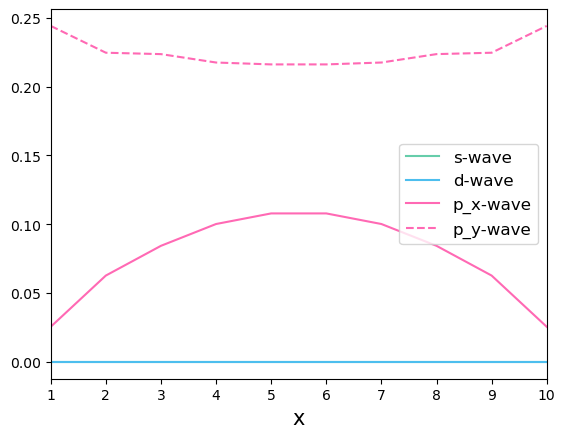

In [5]:
# =============================================================================
# Plot (MATLAB -> matplotlib)
# =============================================================================
color1 = (0.3010, 0.7450, 0.9330)
color2 = (255/255, 105/255, 180/255)
color3 = (102/255, 205/255, 170/255)

x = np.asnumpy(np.arange(1, Nx + 1))

plt.figure()
plt.plot(x, np.asnumpy(np.real(F_swave)), color=color3, label="s-wave")
plt.plot(x, np.asnumpy(np.real(F_dwave)), color=color1, label="d-wave")
plt.plot(x, np.asnumpy(np.real(F_px)),    color=color2, label="p_x-wave")
plt.plot(x, np.asnumpy(np.imag(F_py)),    "--", color=color2, label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, Nx)
plt.legend(fontsize=12, loc="best")
plt.show()

x1 = np.arange(1.5, Nx - 0.5 + 1e-12, 1.0)  # matches MATLAB: 1.5:Nx-0.5

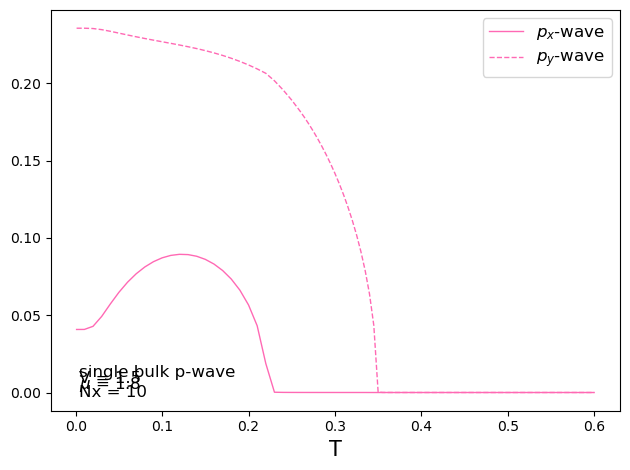

In [6]:
import numpy as np
from numpy import pi
from scipy.linalg import eigh
from joblib import Parallel, delayed
import matplotlib.pyplot as plt


def safe_rel_norm(delta, x, eps=1e-14):
    """
    MATLAB's norm((new-old)./old) will blow up if old has zeros.
    This implements a safe version: divide where |old|>eps, else treat as absolute delta.
    """
    denom = np.where(np.abs(x) > eps, x, 1.0)
    frac = np.where(np.abs(x) > eps, delta / denom, delta)
    return np.linalg.norm(frac)


def build_H1(Nx, t, V, mu, Bx, Bz, Fx_plus, Fx_min):
    """
    Build the k-independent Hamiltonian H1 of size (4Nx, 4Nx).
    Uses site blocks of size 4x4.
    """
    dim = 4 * Nx
    H1 = np.zeros((dim, dim), dtype=np.complex128)

    # On-site diagonal: chemical potential + Bz (Zeeman z)
    onsite_diag = np.array([-mu + Bz, -mu - Bz, +mu - Bz, +mu + Bz], dtype=np.complex128)

    # On-site Bx terms (couplings within the 4x4 block)
    # Matches MATLAB:
    # (1,2)=Bx, (2,1)=Bx, (3,4)=-Bx, (4,3)=-Bx (1-based)
    onsite_Bx = np.zeros((4, 4), dtype=np.complex128)
    onsite_Bx[0, 1] = Bx
    onsite_Bx[1, 0] = Bx
    onsite_Bx[2, 3] = -Bx
    onsite_Bx[3, 2] = -Bx

    # Fill onsite blocks
    for i in range(Nx):
        sl = slice(4 * i, 4 * i + 4)
        H1[sl, sl] += np.diag(onsite_diag) + onsite_Bx

    # Nearest-neighbor hopping along x: off-diagonal blocks
    hop_block = np.diag(np.array([-t, -t, +t, +t], dtype=np.complex128))

    for i in range(Nx - 1):
        sli = slice(4 * i, 4 * i + 4)
        slj = slice(4 * (i + 1), 4 * (i + 1) + 4)
        # Upper diagonal (i, i+1) and lower diagonal (i+1, i)
        H1[sli, slj] += hop_block
        H1[slj, sli] += hop_block

    # Superconductor off-diagonal x-terms (pairing across x bonds)
    # MATLAB:
    # Fx1 = V*Fx_min, Fx2 = V*Fx_plus
    # Upper diag (i, i+1):
    # (1,4)=Fx2, (2,3)=-Fx1, (3,2)=-Fx2, (4,1)=Fx1
    # Lower diag (i+1, i):
    # (1,4)=Fx1, (2,3)=-Fx2, (3,2)=-Fx1, (4,1)=Fx2
    Fx1 = V * Fx_min
    Fx2 = V * Fx_plus

    for i in range(Nx - 1):
        sli = slice(4 * i, 4 * i + 4)
        slj = slice(4 * (i + 1), 4 * (i + 1) + 4)

        upper = np.zeros((4, 4), dtype=np.complex128)
        upper[0, 3] = Fx2[i]
        upper[1, 2] = -Fx1[i]
        upper[2, 1] = -Fx2[i]
        upper[3, 0] = Fx1[i]

        lower = np.zeros((4, 4), dtype=np.complex128)
        lower[0, 3] = Fx1[i]
        lower[1, 2] = -Fx2[i]
        lower[2, 1] = -Fx1[i]
        lower[3, 0] = Fx2[i]

        H1[sli, slj] += upper
        H1[slj, sli] += lower

    return H1


def add_Fy_terms_on_diagonal(H, Nx, V, Fy_plus, Fy_min, ky):
    """
    Adds the y-direction pairing terms that are block-diagonal in x (i.e. onsite per x)
    into the provided Hamiltonian H (in-place).

    MATLAB (inside ky loop):
      Fy_14 = V*(Fy_plus*exp(-iky) + Fy_min*exp(+iky))
      Fy_23 = -V*(Fy_plus*exp(+iky) + Fy_min*exp(-iky))
      Fy_32 = Fy_23'
      Fy_41 = Fy_14'
      Set block entries (1,4),(2,3),(3,2),(4,1) per site.
    """
    e_pos = np.exp(1j * ky)
    e_neg = np.exp(-1j * ky)

    Fy_14 = V * (Fy_plus * e_neg + Fy_min * e_pos)
    Fy_23 = -V * (Fy_plus * e_pos + Fy_min * e_neg)

    for i in range(Nx):
        sl = slice(4 * i, 4 * i + 4)

        H[sl.start + 0, sl.start + 3] += Fy_14[i]          # (1,4)
        H[sl.start + 1, sl.start + 2] += Fy_23[i]          # (2,3)
        H[sl.start + 2, sl.start + 1] += np.conj(Fy_23[i]) # (3,2)
        H[sl.start + 3, sl.start + 0] += np.conj(Fy_14[i]) # (4,1)


def compute_px_py_for_T(
    T,
    Nx=10,
    Ny=100,
    t=1.0,
    V=1.5,
    mu=1.8,
    Bx=0.0,
    Bz=0.0,
    AbsTol=1e-6,
    RelTol=1e-4,
    maxItr=10000,
):
    beta = 1.0 / T

    ky_list = np.linspace(pi / Ny, pi, Ny)

    # Initial values for order parameter (MATLAB)
    Fx_plus = 0.1 * np.ones(Nx - 1, dtype=np.complex128)
    Fx_min  = -0.1 * np.ones(Nx - 1, dtype=np.complex128)
    Fy_plus = 0.1j * np.ones(Nx, dtype=np.complex128)
    Fy_min  = -0.1j * np.ones(Nx, dtype=np.complex128)

    Itr = 0
    c1 = c2 = c3 = True

    # While-loop convergence trackers
    absdiff1 = absdiff2 = absdiff3 = absdiff4 = 100.0
    reldiff1 = reldiff2 = reldiff3 = reldiff4 = 100.0

    while c1 and c2 and c3:
        # Build k-independent part
        H1 = build_H1(Nx, t, V, mu, Bx, Bz, Fx_plus, Fx_min)

        # -------- k = 0 terms (H0) --------
        dim = 4 * Nx
        H0 = np.zeros((dim, dim), dtype=np.complex128)

        # dispersion at ky=0: epsilon0 = -2t*cos(0) = -2t
        eps0 = -2.0 * t
        onsite_disp0 = np.array([eps0, eps0, -eps0, -eps0], dtype=np.complex128)

        for i in range(Nx):
            sl = slice(4 * i, 4 * i + 4)
            H0[sl, sl] += np.diag(onsite_disp0)

        # y-terms at ky=0 use Fy_plus + Fy_min (since exp(±i*0)=1)
        add_Fy_terms_on_diagonal(H0, Nx, V, Fy_plus, Fy_min, ky=0.0)

        # Diagonalise H0 + H1
        eval0, evec0 = eigh(H0 + H1)

        # Extract components (MATLAB: u0=1:4:end, v0=2:4:end, w0=3:4:end, x0=4:4:end)
        u0 = evec0[0::4, :]
        v0 = evec0[1::4, :]
        w0 = evec0[2::4, :]
        x0 = evec0[3::4, :]

        # Fermi-Dirac
        Energies0 = np.tile(eval0[None, :], (Nx, 1))
        f_E0 = 1.0 / (np.exp(beta * Energies0) + 1.0)
        pos_energy = Energies0 > 0.0

        # Pair correlations (k=0) with positive-energy filter, matching MATLAB
        Fx0_ux1 = u0[:-1, :] * np.conj(x0[1:, :]) * (1.0 - f_E0[:-1, :]) * pos_energy[:-1, :]
        Fx0_ux2 = u0[1:, :]  * np.conj(x0[:-1, :]) * (1.0 - f_E0[1:, :])  * pos_energy[1:, :]
        Fx0_vw1 = v0[:-1, :] * np.conj(w0[1:, :]) * f_E0[1:, :]  * pos_energy[1:, :]
        Fx0_vw2 = v0[1:, :]  * np.conj(w0[:-1, :]) * f_E0[:-1, :] * pos_energy[:-1, :]

        Fy0_ux = u0 * np.conj(x0) * (1.0 - f_E0) * pos_energy
        Fy0_vw = v0 * np.conj(w0) * f_E0 * pos_energy

        # Initialise using k=0 contributions
        Fx_plus_new = np.sum(Fx0_ux1 + Fx0_vw2, axis=1).conj().T / Ny
        Fx_min_new  = np.sum(Fx0_ux2 + Fx0_vw1, axis=1).conj().T / Ny

        K_y0 = np.sum(Fy0_ux + Fy0_vw, axis=1).conj().T / Ny
        Fy_plus_new = K_y0.copy()
        Fy_min_new  = K_y0.copy()

        # Singlet / triplet symmetry parts (initialised with k=0)
        FS_x = np.sum(Fx0_ux1 + Fx0_ux2 + Fx0_vw1 + Fx0_vw2, axis=1).conj().T / (2.0 * Ny)
        FS_y = K_y0.copy()

        FT_x_plus = np.sum(Fx0_ux1 - Fx0_ux2 + Fx0_vw2 - Fx0_vw1, axis=1).conj().T / (2.0 * Ny)
        FT_x_min  = np.sum(Fx0_ux2 - Fx0_ux1 + Fx0_vw1 - Fx0_vw2, axis=1).conj().T / (2.0 * Ny)
        FT_y_plus = np.zeros(Nx, dtype=np.complex128)
        FT_y_min  = np.zeros(Nx, dtype=np.complex128)

        # -------- ky loop --------
        for ky in ky_list:
            # k-dependent H2
            H2 = np.zeros((dim, dim), dtype=np.complex128)

            epsilon = -2.0 * t * np.cos(ky)
            onsite_disp = np.array([epsilon, epsilon, -epsilon, -epsilon], dtype=np.complex128)
            for i in range(Nx):
                sl = slice(4 * i, 4 * i + 4)
                H2[sl, sl] += np.diag(onsite_disp)

            add_Fy_terms_on_diagonal(H2, Nx, V, Fy_plus, Fy_min, ky)

            # Full Hamiltonian at this ky
            H = H1 + H2
            evals, evecs = eigh(H)

            u = evecs[0::4, :]
            v = evecs[1::4, :]
            w = evecs[2::4, :]
            x = evecs[3::4, :]

            Energies = np.tile(evals[None, :], (Nx, 1))
            f_E = 1.0 / (np.exp(beta * Energies) + 1.0)

            # Pair correlations (no pos-energy filter here, matching MATLAB ky-loop)
            Fx_ux1 = (u[:-1, :] * np.conj(x[1:, :]) * (1.0 - f_E[:-1, :])).T
            Fx_ux2 = (u[1:, :]  * np.conj(x[:-1, :]) * (1.0 - f_E[1:, :])).T
            Fx_vw1 = (v[:-1, :] * np.conj(w[1:, :]) * f_E[1:, :]).T
            Fx_vw2 = (v[1:, :]  * np.conj(w[:-1, :]) * f_E[:-1, :]).T

            Fy_ux = (u * np.conj(x) * (1.0 - f_E)).T
            Fy_vw = (v * np.conj(w) * f_E).T

            # Update Fx±, Fy±
            Fx_plus_new += np.sum(Fx_ux1 + Fx_vw2, axis=0) / Ny
            Fx_min_new  += np.sum(Fx_ux2 + Fx_vw1, axis=0) / Ny

            Fy_plus_new += np.sum(Fy_ux * np.exp(1j * ky) + Fy_vw * np.exp(-1j * ky), axis=0) / Ny
            Fy_min_new  += np.sum(Fy_ux * np.exp(-1j * ky) + Fy_vw * np.exp(1j * ky), axis=0) / Ny

            # Singlet component
            FS_x += np.sum(Fx_ux1 + Fx_ux2 + Fx_vw1 + Fx_vw2, axis=0) / (2.0 * Ny)
            FS_y += np.sum(Fy_ux + Fy_vw, axis=0) * np.cos(ky) / Ny

            # Triplet component
            FT_x_plus += np.sum(Fx_ux1 - Fx_ux2 + Fx_vw2 - Fx_vw1, axis=0) / (2.0 * Ny)
            FT_x_min  += np.sum(Fx_ux2 - Fx_ux1 + Fx_vw1 - Fx_vw2, axis=0) / (2.0 * Ny)

            FT_y_plus += 1j * np.sum(Fy_ux - Fy_vw, axis=0) * np.sin(ky) / Ny
            FT_y_min  -= 1j * np.sum(Fy_ux - Fy_vw, axis=0) * np.sin(ky) / Ny

        # Filtering out s, d, px, py (same algebra as MATLAB)
        F_swave = (np.r_[0, FS_x] + np.r_[FS_x, 0] + 2.0 * FS_y) / 4.0
        F_dwave = (np.r_[0, FS_x] + np.r_[FS_x, 0] - 2.0 * FS_y) / 4.0
        F_px = (np.r_[0, FT_x_plus] - np.r_[FT_x_min, 0]) / 2.0
        F_py = (FT_y_plus - FT_y_min) / 2.0

        # Convergence measures
        absdiff1 = np.linalg.norm(Fx_plus_new - Fx_plus)
        absdiff2 = np.linalg.norm(Fx_min_new  - Fx_min)
        absdiff3 = np.linalg.norm(Fy_plus_new - Fy_plus)
        absdiff4 = np.linalg.norm(Fy_min_new  - Fy_min)

        reldiff1 = safe_rel_norm(Fx_plus_new - Fx_plus, Fx_plus)
        reldiff2 = safe_rel_norm(Fx_min_new  - Fx_min,  Fx_min)
        reldiff3 = safe_rel_norm(Fy_plus_new - Fy_plus, Fy_plus)
        reldiff4 = safe_rel_norm(Fy_min_new  - Fy_min,  Fy_min)

        # Update iterates
        Fx_plus = Fx_plus_new
        Fx_min  = Fx_min_new
        Fy_plus = Fy_plus_new
        Fy_min  = Fy_min_new

        Itr += 1
        if Itr == maxItr:
            print(f"Warning: Maximum number of iterations reached at T = {T}")

        # Convergence conditions
        c1 = (absdiff1 > AbsTol) or (absdiff2 > AbsTol) or (absdiff3 > AbsTol) or (absdiff4 > AbsTol)
        c2 = (reldiff1 > RelTol) or (reldiff2 > RelTol) or (reldiff3 > RelTol) or (reldiff4 > RelTol)
        c3 = (Itr < maxItr)

    mid = int(round(Nx / 2.0)) - 1  # MATLAB round(Nx/2) with 1-based -> Python 0-based
    return F_px[mid], F_py[mid]


def main():
    # Parameters (matching MATLAB)
    Nx = 10
    Ny = 100
    t = 1.0
    V = 1.5
    mu = 1.8
    Bx = 0.0
    Bz = 0.0

    # T_list = [0.001,0.01:0.01:0.25,0.26:0.005:0.37,0.38:0.01:0.6];
    T_list = np.r_[0.001,
                  np.arange(0.01, 0.25 + 1e-12, 0.01),
                  np.arange(0.26, 0.37 + 1e-12, 0.005),
                  np.arange(0.38, 0.60 + 1e-12, 0.01)]

    # Compute in parallel (parfor equivalent)
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(compute_px_py_for_T)(
            T,
            Nx=Nx, Ny=Ny, t=t, V=V, mu=mu, Bx=Bx, Bz=Bz,
            AbsTol=1e-6, RelTol=1e-4, maxItr=10000
        )
        for T in T_list
    )

    px_list = np.array([r[0] for r in results], dtype=np.complex128)
    py_list = np.array([r[1] for r in results], dtype=np.complex128)

    # Plot
    color2 = np.array([255, 105, 180]) / 255.0  # hot pink

    plt.figure(1)
    plt.clf()
    plt.plot(T_list, np.real(px_list), color=color2, linewidth=1, label=r"$p_x$-wave")
    plt.plot(T_list, np.imag(py_list), "--", color=color2, linewidth=1, label=r"$p_y$-wave")

    plt.text(0.05, 0.085, "single bulk p-wave", fontsize=12, transform=plt.gca().transAxes)
    plt.text(0.05, 0.07,  f"V = {V}", fontsize=12, transform=plt.gca().transAxes)
    plt.text(0.05, 0.055, rf"$\mu$ = {mu}", fontsize=12, transform=plt.gca().transAxes)
    plt.text(0.05, 0.035, f"Nx = {Nx}", fontsize=12, transform=plt.gca().transAxes)

    plt.xlabel("T", fontsize=15)
    plt.legend(loc="best", fontsize=12)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


In [7]:
# import cupy as cp

# Fx_plus = cp.ones((Nx-1,Ny), dtype=cp.complex128) * 0.1
# Fx_minus = cp.ones((Nx-1,Ny), dtype=cp.complex128) * 0.1
# Fy_plus = cp.ones((Nx,Ny-1), dtype=cp.complex128) * 0.1
# Fy_minus= cp.ones((Nx,Ny-1), dtype=cp.complex128) * 0.1

# Fuux_plus = cp.ones((Nx-1,Ny), dtype=cp.complex128) * 0.0
# Fuux_minus = cp.ones((Nx-1,Ny), dtype=cp.complex128) * 0.0
# Fuuy_plus = cp.ones((Nx,Ny-1), dtype=cp.complex128) * 0.0
# Fuuy_minus = cp.ones((Nx,Ny-1), dtype=cp.complex128) * 0.0

# Fddx_plus = cp.ones((Nx-1,Ny), dtype=cp.complex128) * 0.0
# Fddx_minus = cp.ones((Nx-1,Ny), dtype=cp.complex128) * 0.0
# Fddy_plus = cp.ones((Nx,Ny-1), dtype=cp.complex128) * 0.0
# Fddy_minus = cp.ones((Nx,Ny-1), dtype=cp.complex128) * 0.0


# gap_s = V * (F["+x"] + F["-x"] + F["+y"] + F["-y"])/4
# gap_d = V * (F["+x"] + F["-x"] - F["+y"] - F["-y"])/4
# gap_px = V * (F["+x"] - F["-x"])/2
# gap_py = V * (F["+y"] - F["-y"])/2
# gap_px_uu = V_prime * (Fuu["+x"] - Fuu["-x"])/2
# gap_py_uu = V_prime * (Fuu["+y"] - Fuu["-y"])/2
# gap_px_dd = V_prime * (Fdd["+x"] - Fdd["-x"])/2
# gap_py_dd = V_prime * (Fdd["+y"] - Fdd["-y"])/2